# Advanced Plotting
## PyIU Advanced Python Workshop for Alice Palma

Authors: Kristin Baker

Last modified: 6/2/2026

This notebook introduces the fundamental elements of plotting with Matplotlib.

Data visualization (i.e. plotting) is one of the most important aspects in coding as that is the main way you convey important data to your audience. In this section, we will go over important aspects of a plot and how to implement them via code!

First, we will begin by importing the Python package for plotting data: "Matplotlib." If you are interested in learning more about Matplotlib beyond this tutorial, you can go to https://matplotlib.org/stable/gallery/index.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Plotting Basics with Pyplot (plt)

There are two main plotting classes in Matplotlib: Pyplot and Axes. They both have their own pros and cons. Pyplot is sufficient for simple plotting task while Axes is better for more advanced plotting (e.g., using subplots, color bars, etc.). First, there is a quick demo of Pyplot as a review of plotting basics, but we will focus on advanced plotting with Axes.

When making plots, it is best practice to include the following in your plot:
1) Axis labels
2) Plot title
3) Legend (especially when working with multiple data sets)

<center><img src="https://raw.githubusercontent.com/pyiu-workshops/pyiu/refs/heads/main/crash-course/blackbody-spectra/imgs/sample_matplotlib_plot.png" alt="Sample matplotlib plot, showing key elements like axis labels, tick labels, a legend, and a title"/></center>

There are different types of functions for different types of plotting. For example, when plotting discrete data points (e.g., a scatter plot), you would use `plt.scatter`. In this case, we will use the `plt.plot` function which draws a line from point to point.

Within the plot function, we can specify certain parameters using arguments. The main parameters you want to set everytime are:

*   Color
*   Line Width
*   Line Style
*   Label

The color, line width, and line style have to do with aesthetic of the plot (which is just as important as the data in the plot!). However, the label will set what information is relayed in the legend.

In [2]:
# Generating data
x_data1 = np.linspace(0, 20, 20)
y_data1 = -(x_data1 - 10)**2 + 100

There are many different ways to plot data (e.g., lines, scatter plots, histograms, etc.), but we will focus on plotting a line.

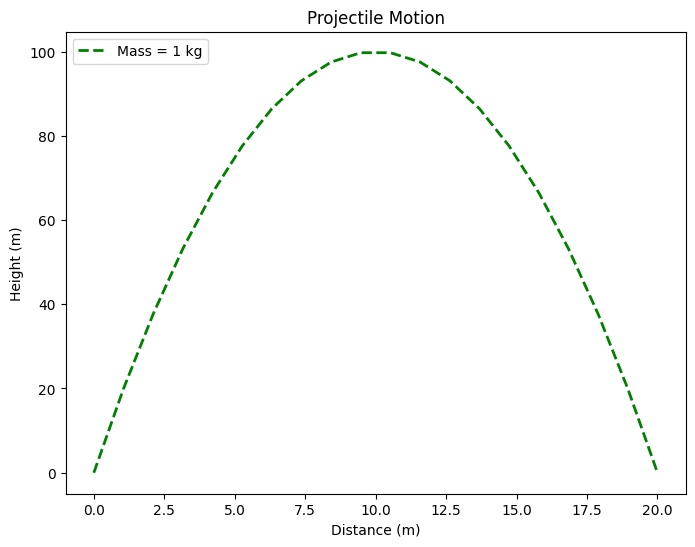

In [3]:
# Set the figure width and height
fig = plt.figure(figsize=(8, 6))

# Plot the data
plt.plot(x_data1, y_data1, color='green', linewidth=2, linestyle='--', label="Mass = 1 kg")

# Set the x-axis label
plt.xlabel("Distance (m)")

# Set the y-axis label
plt.ylabel("Height (m)")

# Set the plot title
plt.title("Projectile Motion")

# Set the legend
plt.legend(loc="upper left")

# Save the figure
# plt.savefig("projectile_motion.png")

# Show the plot
plt.show()

### Advanced Plotting with Axes (ax)

Axes allows us to have more control of our figures and plots. This is most helpful for research plots.

We can import some helpful functions within the matplotlib package that we can use with Axes.

#### General Plot Customizations

There are many aspects of a plot we can customize. In this section we discuss customizing: 
* Markers
* Legends
* Error bars
* Tick parameters

First, we will generate random data for our plots.

In [4]:
# The random.seed function guarantees that any random functions produce the same values each time the code is run, making them easier to test
np.random.seed(1240)
arr1 = np.random.randint(low=1, high=300, size=50)/100
arr1_err = np.random.randint(low=1, high=30, size=50)/100

np.random.seed(87)
arr2 = np.random.randint(low=1, high=300, size=50)/100
arr2_err = np.random.randint(low=1, high=30, size=50)/100

np.random.seed(6540)
arr3 = np.random.randint(low=1, high=300, size=50)/100

np.random.seed(982)
arr4 = np.random.randint(low=1, high=300, size=50)/100

Let's start with the basics using the Axes class.

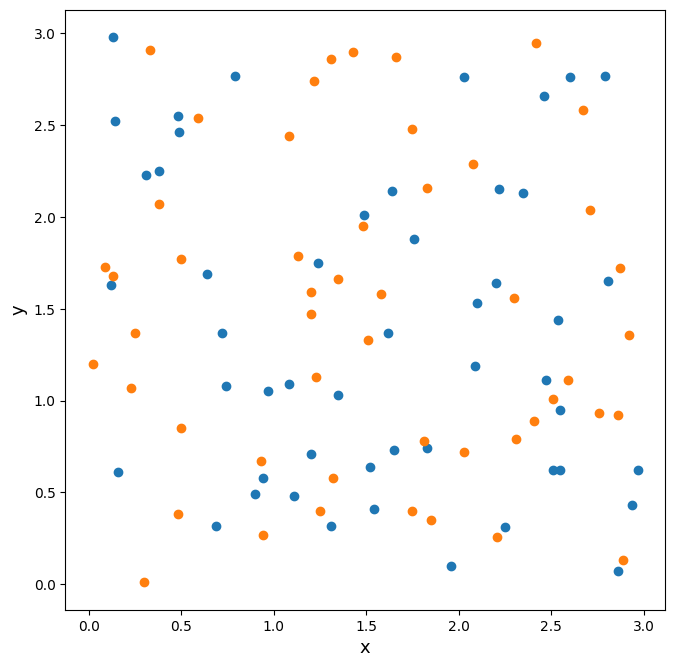

In [5]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1])

ax.scatter(arr1, arr2, color='tab:blue', label="Population 1")
ax.scatter(arr3, arr4, color='tab:orange', label="Population 2")
ax.set_xlabel("x", fontsize=13)
ax.set_ylabel("y", fontsize=13)

plt.show()

Now, we'll customize it a little. First let's start with the markers. Whenever you plot data that represent different samples, it is a good practice to use different markers and colors. This makes plots easier to interepret and more accessible. The marker can be set with the keyword argument `marker`. Here are the available markers in matplotlib: https://matplotlib.org/stable/api/markers_api.html. You may also want to change the size with the `s` keyword argument.

Note: here is a resource for choosing accessible color palletes (https://davidmathlogic.com/colorblind/#%231E88E5-%23FF923A-%23E972E1). You can also set colors with hexadecimal color codes (e.g., `color="#2e93ff"` gives a tealish blue color).

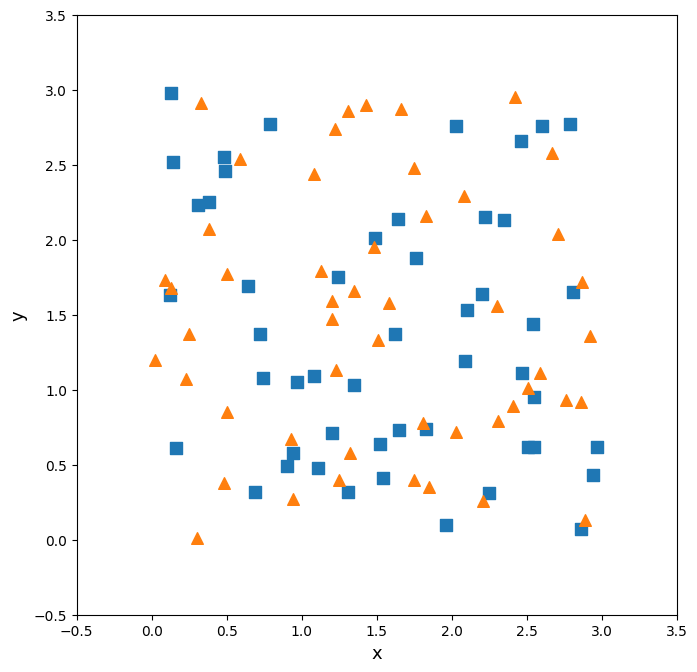

In [6]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1])

ax.scatter(arr1, arr2, color='tab:blue', label="Population 1", marker="s", s=70)
ax.scatter(arr3, arr4, color='tab:orange', label="Population 2", marker="^", s=70)
ax.set_xlabel("x", fontsize=13) 
ax.set_ylabel("y", fontsize=13) 

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)

plt.show()

Next, you may want to customize your x and y axes. 

We can use `ax.set_xticks` to specify which ticks receive labels.

The function `ax.tick_params` lets us customize the appearance of ticks, tick labels, and gridlines. The main parameters include:
* `labelsize` = the font size of your tick labels
* `axis` = the axis you are customizing ('x', 'y', or 'both')
* `which` = the group of ticks you are customizing ('major', 'minor', or 'both')
* `length` = how long you want the tick marks to be
* `width` = how wide you want the tick marks to be

We can use `ax.xaxis.set_minor_locator` to set minor tick marks. Setting `ax.xaxis.set_ticks_position` to "both" adds tick marks to the minor axes (very common for research plots).

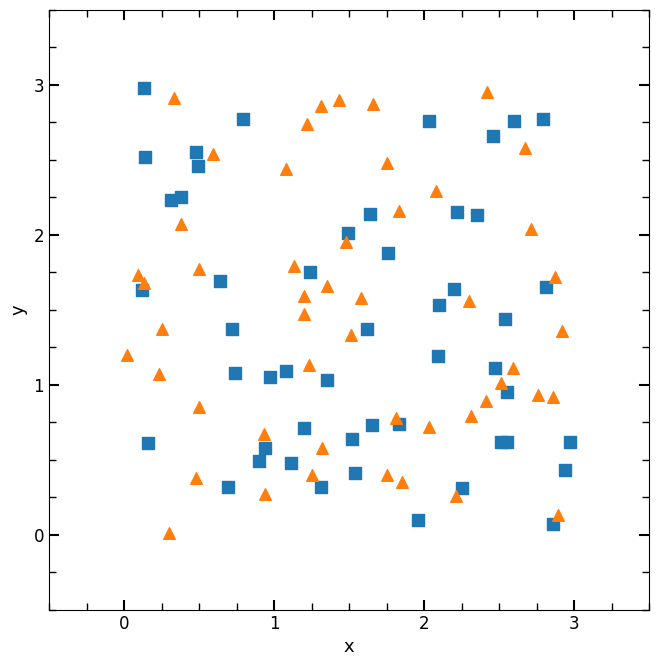

In [7]:
from matplotlib.ticker import AutoMinorLocator

fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1])

ax.scatter(arr1, arr2, color='tab:blue', label="Population 1", marker="s", s=70)
ax.scatter(arr3, arr4, color='tab:orange', label="Population 2", marker="^", s=70)

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)

ax.set_xlabel("x", fontsize=13) 
ax.set_xticks([0, 1, 2, 3])
ax.set_ylabel("y", fontsize=13)
ax.set_yticks([0, 1, 2, 3])

ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.tick_params(labelsize=12, direction='in') 
ax.tick_params(which='major', length=7, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', length=5, width=1, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

plt.show()

Now, let's say that our data has error bars, which is a very likely scenario when making research plots. We can use the `ax.errorbar` function to add error bars. Read more here: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html.

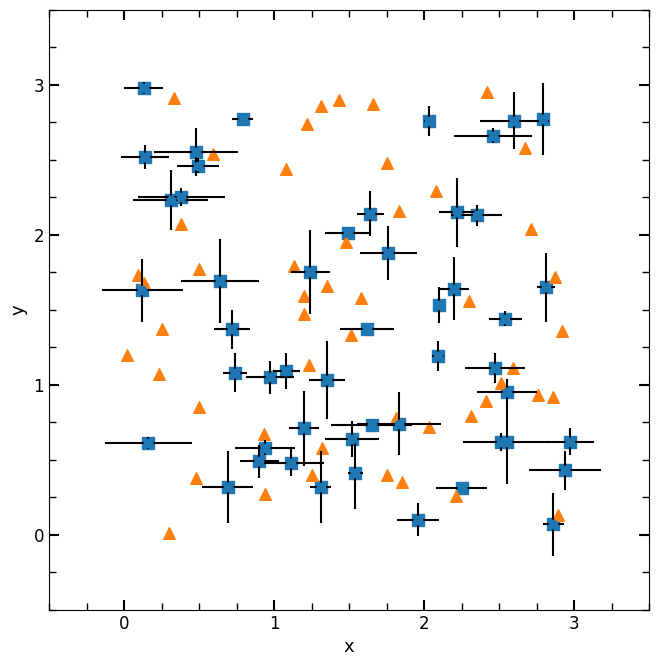

In [8]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1])

ax.errorbar(arr1, arr2, xerr=arr1_err, yerr=arr2_err, fmt='o', ecolor='k')
ax.scatter(arr1, arr2, color='tab:blue', label="Population 1", marker="s", s=70)

ax.scatter(arr3, arr4, color='tab:orange', label="Population 2", marker="^", s=70)

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)

ax.set_xlabel("x", fontsize=13) 
ax.set_xticks([0, 1, 2, 3])
ax.set_ylabel("y", fontsize=13)
ax.set_yticks([0, 1, 2, 3])

ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.tick_params(labelsize=12, direction='in')
ax.tick_params(which='major', length=7, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', length=5, width=1, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

plt.show()

Now let's customize the legend. We can change the location of the legend on the plot with the `loc` keyword argument of `ax.legend`. We can also use the `bbox_to_anchor` keyword argument to set the legend outside the plot.

Read more: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html.

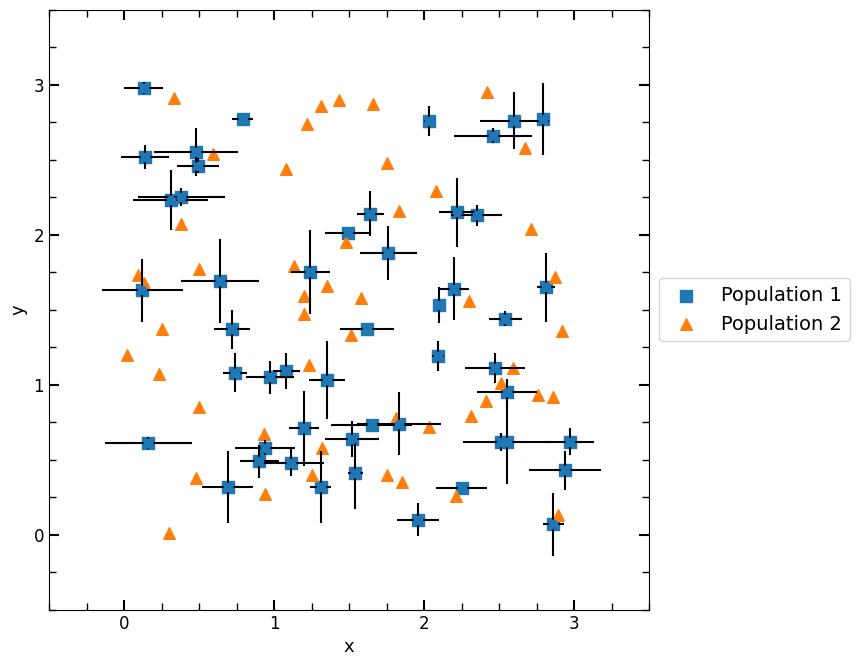

In [9]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0, 0, 1, 1])

ax.errorbar(arr1, arr2, xerr=arr1_err, yerr=arr2_err, fmt='o', ecolor='k')
ax.scatter(arr1, arr2, color='tab:blue', label="Population 1", marker="s", s=70)

ax.scatter(arr3, arr4, color='tab:orange', label="Population 2", marker="^", s=70)

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)

ax.set_xlabel("x", fontsize=13) 
ax.set_xticks([0, 1, 2, 3])
ax.set_ylabel("y", fontsize=13)
ax.set_yticks([0, 1, 2, 3])

ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.tick_params(labelsize=12, direction='in')
ax.tick_params(which='major', length=7, width=1.5, direction='in')
ax.tick_params(axis='both', which='minor', length=5, width=1, direction='in')
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=14)

plt.show()

#### Subplots

Using Axes allows you to use gridspec (https://matplotlib.org/stable/api/_as_gen/matplotlib.gridspec.GridSpec.html), a versatile tool for creating subplots.

In [10]:
# Let's generate some data for this section
# Population 1
np.random.seed(1240)
rand_hist1 = np.random.randint(low=1, high=100, size=100)

# Population 2
np.random.seed(87)
rand_hist2 = np.random.randint(low=1, high=100, size=100)

list1 = [rand_hist1, rand_hist2]

We can make simple subplots with the `plt.subplots()` function.

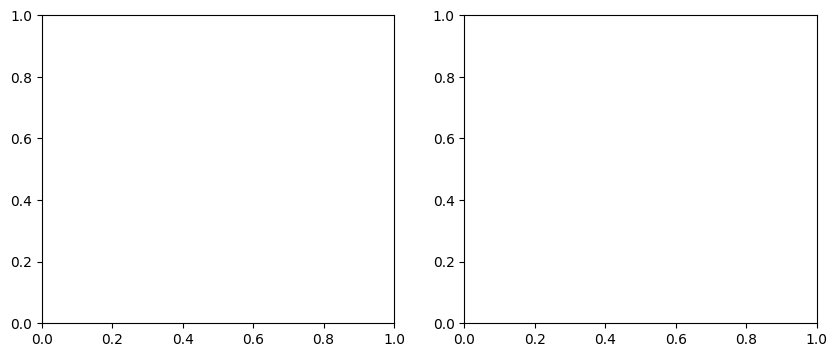

In [11]:
# Set number of subplots: ncols = numbers of columns, nrows = number of rows
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plt.show()

However, we can use Gridspec to customize our plots more.

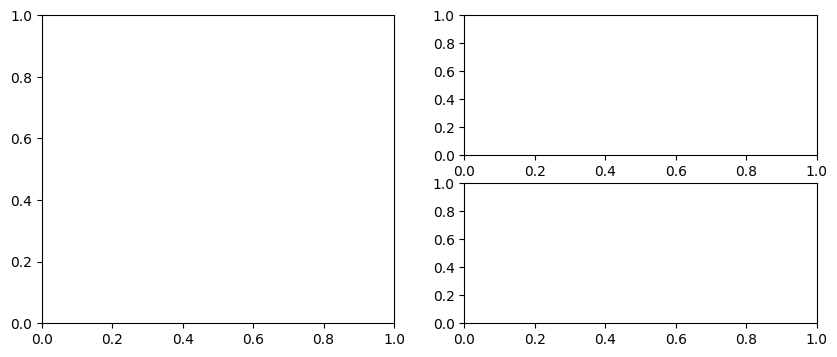

In [12]:
import matplotlib.gridspec as gridspec

# Set the size of the overall figure
fig = plt.figure(figsize=(10, 4))

# Set number of subplots
grid = gridspec.GridSpec(ncols=2, nrows=2, figure=fig)

# Set up subplots
ax0 = fig.add_subplot(grid[:, 0])
ax1 = fig.add_subplot(grid[0, 1])
ax2 = fig.add_subplot(grid[1, 1])
ax = [ax0, ax1, ax2]

plt.show()

In this section, we will plot histograms in our subplots. See the `ax.hist` documentation for more ways to customize histograms! https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html

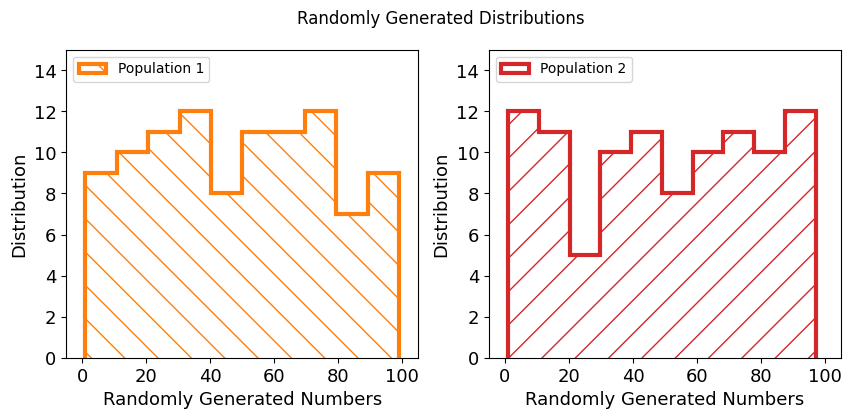

In [ ]:
# Set the size of the overall figure
fig = plt.figure(figsize=(10, 4))

# Set number of subplots
grid = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)

# Set up subplots
ax0 = fig.add_subplot(grid[0, 0])
ax1 = fig.add_subplot(grid[0, 1])
ax = [ax0, ax1]

# Customize the histogram by setting the histtype, linewidth, color, and hatch
ax0.hist(rand_hist1, histtype='step', lw=3, color='tab:orange', hatch='\\', label='Population 1')
ax1.hist(rand_hist2, histtype='step', lw=3, color='tab:red', hatch='/', label='Population 2')

# When you are working with subplots and you want all of them to have the same parameters,
# you can use a for loop to set them more efficiently
for i in range(len(ax)):
  ax[i].tick_params(labelsize=13)
  ax[i].set_xlabel("Randomly Generated Numbers", fontsize=13)
  ax[i].set_ylabel("Distribution", fontsize=13)
  ax[i].set_ylim(0, 15)
  ax[i].set_xlim(-5, 105)
  ax[i].legend(loc='upper left')

# Set the figure title
fig.suptitle("Randomly Generated Distributions")

plt.show()

#### More Fun... Colormaps

See here for a thorough description of colormaps in Matplotlib: https://matplotlib.org/stable/users/explain/colors/colormaps.html

In [14]:
# Let's generate data for this section
# x
np.random.seed(1240)
NII = np.random.randint(low=-80, high=25, size=25)/100

# y
np.random.seed(87)
OIII = np.random.randint(low=4, high=13, size=25)/10

# Color scale
np.random.seed(87)
color_scale = np.random.randint(low=830, high=890, size=25)/100

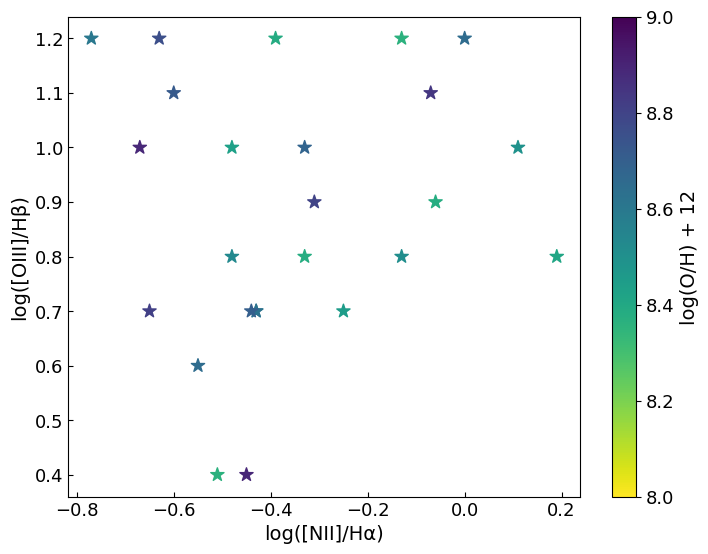

In [15]:
orig_map = plt.get_cmap('viridis')  # Choose color scheme
reversed_map = orig_map.reversed() # You can flip the order; in this example, higher values are darker colors

fig3 = plt.figure()
ax = fig3.add_axes([0, 0, 1, 1])

# Create the color bar
cax = ax.scatter(NII, OIII, c=color_scale, s=100, marker='*', cmap=reversed_map, vmin=8.0, vmax=9.0)
cbar1 = plt.colorbar(cax, orientation="vertical")
cbar1.ax.tick_params(labelsize=13)
cbar1.set_label(label="log(O/H) + 12", size=14)

ax.set_xlabel("log([NII]/H\u03B1)", fontsize=14) # You can introduce special characters, like Greek letters, by using their unicode representation
ax.set_ylabel("log([OIII]/H\u03B2)", fontsize=14)
ax.tick_params(labelsize=13, direction='in')

plt.show()

#### Other Resources
1.   Inset Plots - https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.inset_axes.html

2.   3D Plots - https://www.geeksforgeeks.org/three-dimensional-plotting-in-python-using-matplotlib/

3.   Animations - https://matplotlib.org/stable/users/explain/animations/animations.html

## Explore all you can do with Matplotlib here: https://matplotlib.org/stable/gallery/index.html